In [248]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# PBL 1

5 days
1 minute

Component Abbreviations:
- B = bacterial concentration (streptococcus pyogenes)
- A = antibiotic concentration (amoxicillin)
- N = neutrophil concentration
- I = antibody concentration (IgG)

Compartment Abbreviations:
- epi = epithelial cell surface
- lym = lymphatic system
- cir = circulatory system
- sto = stomach
- bone = bone marrow

Other Abbreviations:
- pro = proliferation/production rate
- elim = death/clearance/elimination rate
- t = transfer rate
- abs = absorption rate

## Initial Conditions:

In [249]:
epiB0 = 1e4 # initial bacterial concentration on epithelial cell surface (CFU/mL)
cirN0 = 5000 * 1000 # initial neutrophil concentration in circulatory system (cells/mL)
lymN0 = 0 # initial neutrophil concentration in lymphatic system (mg/mL)
epiN0 = 0 # initial neutrophil concentration on epithelial cell surface (mg/mL)
cirI0 = 0 # initial antibody concentration in circulatory system (mg/mL)
lymI0 = 0 # initial antibody concentration in lymphatic system (mg/mL)
epiI0 = 0 # initial antibody concentration on epithelial cell surface (mg/mL)

## Constants:

In [250]:
# Bacteria:
proB = np.log(2) / 1 # bacterial proliferation rate
elimBfromA = 0.8 # bacterial death rate due to amoxicillin
elimBfromN = 0.82 # initial bacterial death rate due to neutrophils
elimBfromI = 0.5 # bacterial death rate due to antibodies (COME BACK)
tBEpitoLym = 0.02 # transfer rate of bacteria from epithelial cell surface to lymphatic system (find source?)
# tBLymtoCir = 0 # transfer rate of bacteria from lymphatic system to circulatory system

# NEED TRANSFER RATES FOR BACTERIA BETWEEN COMPARTMENTS!!!

# Amoxicillin:
doseA = 0.8 * 500 / 5000 # standard dose of amoxicillin (mg)
absA = 0.7 # absorption rate of amoxicillin
elimA = 2 # elimination rate of amoxicillin
tACirtoLym = 0.92 # transfer rate of amoxicillin from circulatory system to lymphatic system
tALymtoCir = 1.99 # transfer rate of amoxicillin from lymphatic system to circulatory system
tACirtoEpi = 0.82 # transfer rate of amoxicillin from circulatory system to epithelial cell surface
tAEpitoCir = 4.42 # transfer rate of amoxicillin from epithelial cell surface to circulatory system

# Neutrophils:
proN = 7.5e10 / (24 * 5000) # neutrophil proliferation rate (cells/mL/hr) (COME BCK)
elimN = 0.0462 # neutrophil death rate
tNCirtoLym = 0.0077 # transfer rate of neutrophils from circulatory system to lymphatic system
tNLymtoCir = 0.0077 # transfer rate of neutrophils from lymphatic system to circulatory system
tNCirtoEpi = 0.0077 # transfer rate of neutrophils from circulatory system to epithelial cell surface
tNEpitoCir = 0.0077 # transfer rate of neutrophils from epithelial cell surface to circulatory system

#Assumption ^^^

# Antibodies:
proI = 860 / 24 # antibody production rate (mg/hr)
elimI = np.log(2) / (23 * 24) # antibody elimination rate (half-life of 23 days)
tILymtoCir = 0.12 / 6 # transfer rate of antibodies from lymphatic system to circulatory system
tICirtoLym = 0.737 / 24 # transfer rate of antibodies from circulatory system to lymphatic system
tIEpitoCir = 0.737 / 24 # transfer rate of antibodies from epithelial cell surface to circulatory
tICirtoEpi = tIEpitoCir # transfer rate of antibodies from circulatory system to epithelial cell surface

## Variables:

In [251]:
t = np.linspace(0, 120, 7200) # time vector for 5 days in hours

# cirB = np.zeros(7200) # bacterial concentration in circulatory system
lymB = np.zeros(7200) # bacterial concentration in lymphatic system
epiB = np.zeros(7200) # bacterial concentration on epithelial cell surface
epiB[0] = epiB0

cirA = np.zeros(7200) # amoxicillin concentration in circulatory system
lymA = np.zeros(7200) # amoxicillin concentration in lymphatic system
epiA = np.zeros(7200) # amoxicillin concentration on epithelial cell surface

cirN = np.zeros(7200) # neutrophil concentration in circulatory system
cirN[0] = cirN0
lymN = np.zeros(7200) # neutrophil concentration in lymphatic system
lymN[0] = lymN0
epiN = np.zeros(7200) # neutrophil concentration on epithelial cell surface
epiN[0] = epiN0

cirI = np.zeros(7200) # antibody concentration in circulatory system
cirI[0] = cirI0
lymI = np.zeros(7200) # antibody concentration in lymphatic system
lymI[0] = lymI0
epiI = np.zeros(7200) # antibody concentration on epithelial cell surface
epiI[0] = epiI0

## Hill Equations:

In [252]:
def hill(x, k):
    return x / (k + x)

def rHill(x, k):
    return k / (k + x)

## Bacterial Rate Equations:

In [253]:
def dBdtLym(_lymB, _lymA, _lymN, _lymI, _epiB):
    return (proB * _lymB
            - elimBfromA * hill(_lymA, 0.016 * 0.001) * _lymB
            - elimBfromN * hill(_lymN, 1.19e6) * _lymB
            - elimBfromI * hill(_lymI, 0.02) * _lymB # where was k value from???
            + tBEpitoLym * _epiB)

def dBdtEpi(_epiB, _epiA, _epiN, _epiI, _lymB):
    return (proB * _epiB
            - elimBfromA * hill(_epiA, 0.016 * 0.001) * _epiB
            - elimBfromN * hill(_epiN, 1.19e6) * _epiB
            - elimBfromI * hill(_epiI, 0.02) * _lymB
            - tBEpitoLym * _epiB)

## Amoxicillin Rate Equations:

In [254]:
def dAdtCir(_doseA, _cirA, _lymA, _epiA):
    # return 0
    return (absA * _doseA - elimA * _cirA
           + tALymtoCir * _lymA
           - tACirtoLym * _cirA
           + tAEpitoCir * _epiA
           - tACirtoEpi * _cirA)

def dAdtLym(_cirA, _lymA): return tACirtoLym * _cirA - tALymtoCir * _lymA - elimA * _lymA

def dAdtEpi(_cirA, _epiA): return tACirtoEpi * _cirA - tAEpitoCir * _epiA - elimA * _epiA

## Neutrophil Rate Equations:

In [255]:
def dNdtCir(_cirN, _lymN, _epiN):
    # return 0
    return (proN - elimN * _cirN
           + tNLymtoCir * _lymN
           - tNCirtoLym * _cirN
           + tNEpitoCir * _epiN
           - tNCirtoEpi * _cirN)

def dNdtLym(_lymN, _cirN, _epiN):
    # return 0
    return tNCirtoLym * _cirN - tNLymtoCir * _lymN - elimN * _lymN

def dNdtEpi(_epiN, _cirN):
    # return 0
    return tNCirtoEpi * _cirN - tNEpitoCir * _epiN - elimN * _epiN

## Antibody Rate Equations:

In [256]:
def dIdtCir(_cirI, _lymI, _epiI):
    # return 0
    return (tILymtoCir * _lymI
            - tICirtoLym * _cirI
            + tICirtoEpi * _cirI
            - tIEpitoCir * _epiI
            - elimI * _cirI)

def dIdtLym(_lymI, _epiB, _cirI):
    # return 0
    return (proI * hill(_epiB, 1e4) - elimI * _lymI # proI
            + tICirtoLym * _cirI
            - tILymtoCir * _lymI)

def dIdtEpi(_cirI, _epiI):
    # return 0
    return tICirtoEpi * _cirI - tIEpitoCir * _epiI - elimI * _epiI

## Dosage Rate Equation:

In [257]:
def dDosedt(_doseA):

    return -absA * _doseA

## Total Rate Equation:

In [258]:
def dYdt(t, y):
    _lymB, _epiB, _cirA, _lymA, _epiA, _cirN, _lymN, _epiN, _cirI, _lymI, _epiI, _doseA = y

    return [dBdtLym(_lymB, _lymA, _lymN, _lymI, _epiB),
            dBdtEpi(_epiB, _epiA, _epiN, _epiI, _lymB),
            dAdtCir(_doseA, _cirA, _lymA, _epiA),
            dAdtLym(_cirA, _lymA),
            dAdtEpi(_cirA, _epiA),
            dNdtCir(_cirN, _lymN, _epiN),
            dNdtLym(_lymN, _cirN, _epiN),
            dNdtEpi(_epiN, _cirN),
            dIdtCir(_cirI, _lymI, _epiI),
            dIdtLym(_lymI, _epiB, _cirI),
            dIdtEpi(_cirI, _epiI),
            dDosedt(_doseA)]

In [259]:
t0, tf = 0, 120 # time span for 5 days in hours

doseInterval = 12 # hours between doses

y = [0, epiB0, 0, 0, 0, cirN0, lymN0, epiN0, cirI0, lymI0, epiI0, doseA] # initial conditions for all variables

T = [] # time points
Y = [] # variable values at each time point

t = t0

while t < tf:
    t_next = min(t + doseInterval, tf) # next time point for dose or end of simulation

    sol = scipy.integrate.solve_ivp(dYdt, (t, t_next), y, method='Radau') # solve the ODEs from current time to next dose time

    T.extend(sol.t) # append time points from the solution
    Y.extend(sol.y.T) # append variable values from the solution (transpose to match time points)

    y = sol.y[:, -1] # get the last values of the variables
    t = t_next # update time to the next dose time

    if t < tf:
        y[-1] += 0.8 * 500 / 5000 # administer another dose of amoxicillin

Y = np.array(Y) # convert list to array
T = np.array(T) # convert list to array

lymB = Y[:, 0] # bacterial concentration in lymphatic system
epiB = Y[:, 1] # bacterial concentration on epithelial cell surface

cirA = Y[:, 2] # amoxicillin concentration in circulatory system
lymA = Y[:, 3] # amoxicillin concentration in lymphatic system
epiA = Y[:, 4] # amoxicillin concentration on epithelial cell surface

cirN = Y[:, 5] # neutrophil concentration in circulatory system
lymN = Y[:, 6] # neutrophil concentration in lymphatic system
epiN = Y[:, 7] # neutrophil concentration on epithelial cell surface

cirI = Y[:, 8] # antibody concentration in circulatory system
lymI = Y[:, 9] # antibody concentration in lymphatic system
epiI = Y[:, 10] # antibody concentration on epithelial cell surface

doseA = Y[:, 11] # dose of amoxicillin remaining in stomach

t = T

## Plots:

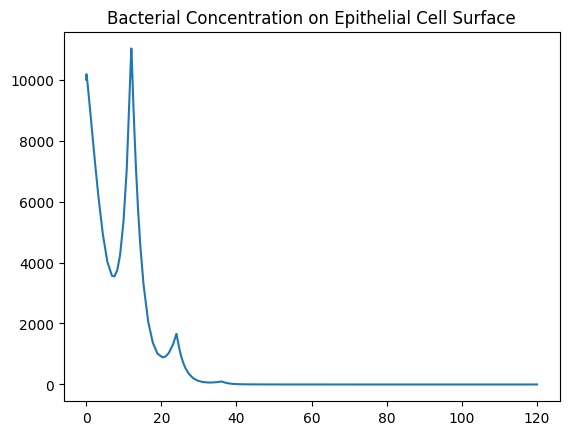

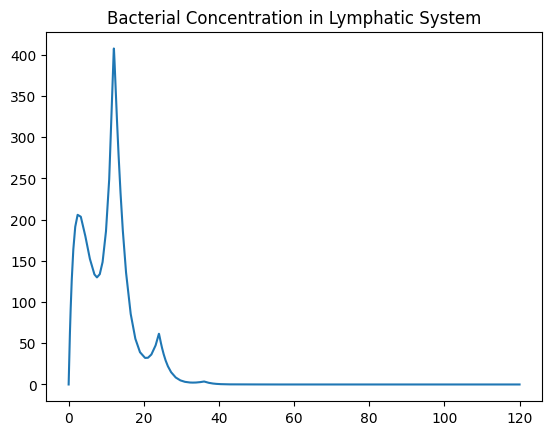

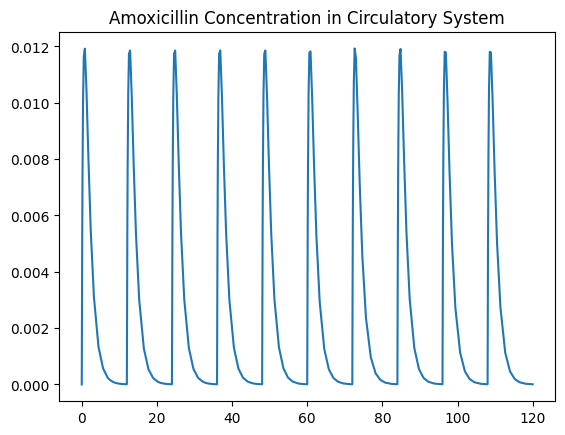

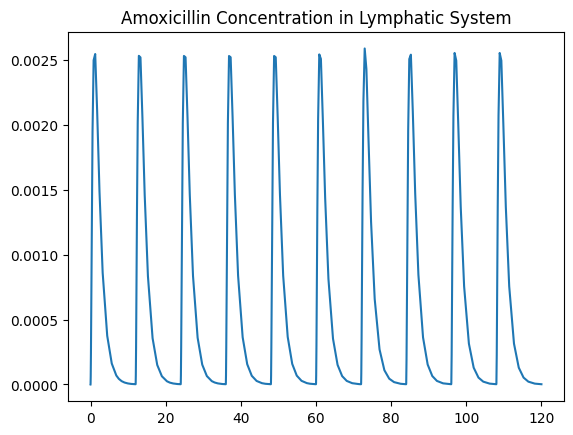

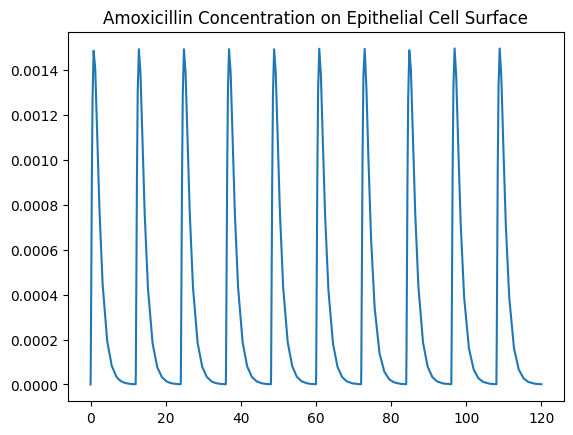

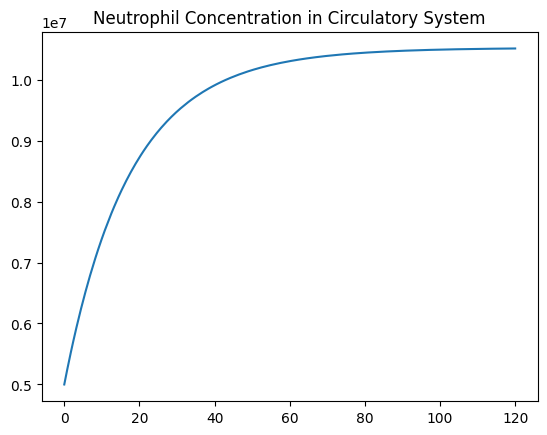

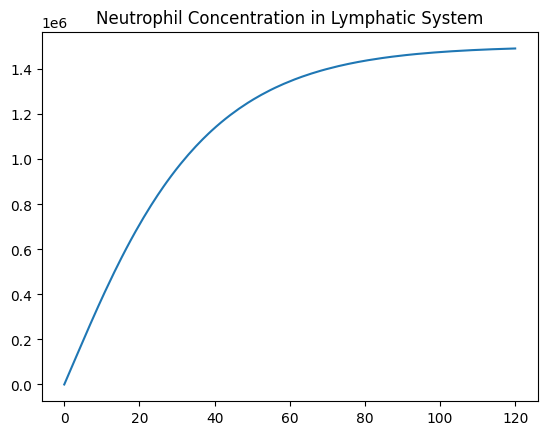

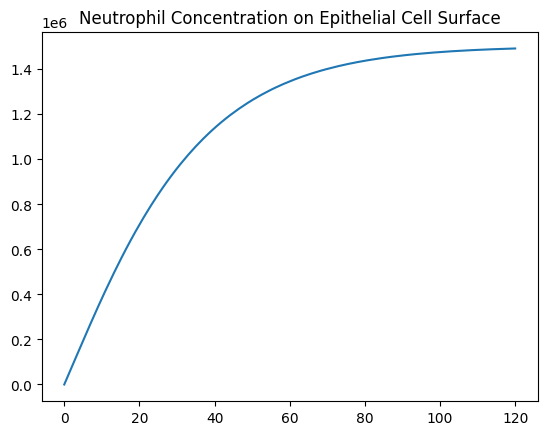

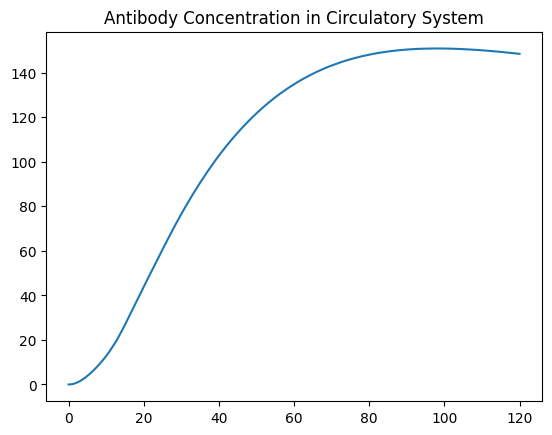

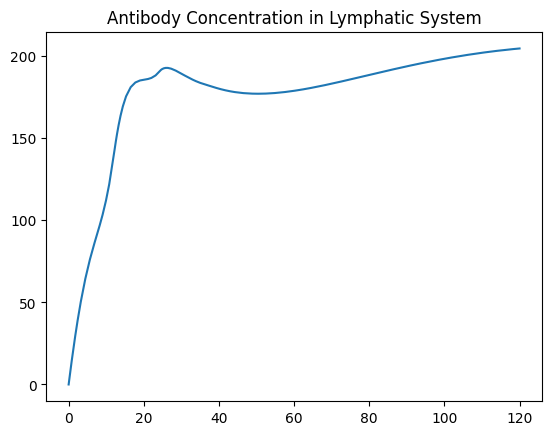

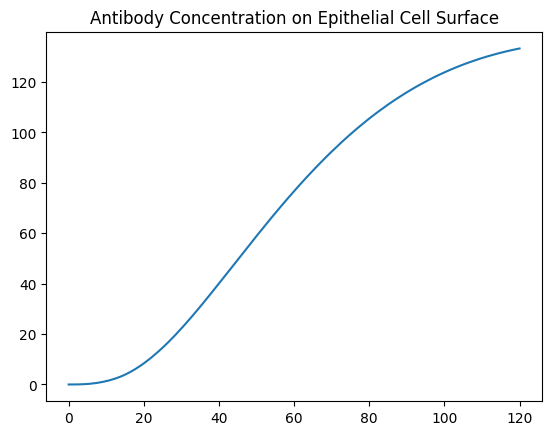

In [260]:
plt.plot(t, epiB, label='Bacterial Concentration on Epithelial Cell Surface')
plt.title('Bacterial Concentration on Epithelial Cell Surface')
plt.show()

plt.plot(t, lymB, label='Bacterial Concentration in Lymphatic System')
plt.title('Bacterial Concentration in Lymphatic System')
plt.show()

plt.plot(t, cirA, label='Amoxicillin Concentration in Circulatory System')
plt.title('Amoxicillin Concentration in Circulatory System')
plt.show()

plt.plot(t, lymA, label='Amoxicillin Concentration in Lymphatic System')
plt.title('Amoxicillin Concentration in Lymphatic System')
plt.show()

plt.plot(t, epiA, label='Amoxicillin Concentration on Epithelial Cell Surface')
plt.title('Amoxicillin Concentration on Epithelial Cell Surface')
plt.show()

plt.plot(t, cirN, label='Neutrophil Concentration in Circulatory System')
plt.title('Neutrophil Concentration in Circulatory System')
plt.show()

plt.plot(t, lymN, label='Neutrophil Concentration in Lymphatic System')
plt.title('Neutrophil Concentration in Lymphatic System')
plt.show()

plt.plot(t, epiN, label='Neutrophil Concentration on Epithelial Cell Surface')
plt.title('Neutrophil Concentration on Epithelial Cell Surface')
plt.show()

plt.plot(t, cirI, label='Antibody Concentration in Circulatory System')
plt.title('Antibody Concentration in Circulatory System')
plt.show()

plt.plot(t, lymI, label='Antibody Concentration in Lymphatic System')
plt.title('Antibody Concentration in Lymphatic System')
plt.show()

plt.plot(t, epiI, label='Antibody Concentration on Epithelial Cell Surface')
plt.title('Antibody Concentration on Epithelial Cell Surface')
plt.show()